# Simulating the Brownian Bridge

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [4]:
def simulate_brownian_bridge(n_paths, n_steps, T=1.0, W_T=0):
    """
    Simulate a Brownian bridge from 0 to W_T over time interval [0, T].
    T: total time of the Brownian bridge (e.g., 1.0)
    W_T: the value at time T (the endpoint of the Brownian bridge)
    """
    dt = T / n_steps # 1.0 is the total time of the Brownian bridge, why? Because we want to simulate a Brownian bridge that starts at 0 at time 0 and ends at 0 at time 1. The total time interval is therefore 1, and we divide it into n_steps to get the time step size dt.
    # n_steps+1 because we want to include the final time point t=1
    time_axis = np.linspace(0, T, n_steps + 1) # Shape (n_steps + 1,)
    # Generate Standard Brownian motion B(t)
    # Increments: dW ~ N(0, sqrt(dt))
    increments = np.random.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    # Cumulative sum to get paths
    # This generates a normal, unconstrained standard Brownian motion B(t). Because it is unconstrained, 
    # at the final time step (t=1), the paths will be scattered all over the place. Some will end at +2, some at -1.5, etc.
    B = np.zeros((n_paths, n_steps + 1))
    B[:, 1:] = np.cumsum(increments, axis=1)

    # [np.newaxis, :] forces Python to keep it as a 2D column vector.
    # This looks at the very last column of the matrix (B[:, -1]) to see exactly where each individual random path accidentally landed at t=1. 
    # This final value is B(1).
    B_T = B[:, -1][:, np.newaxis] # Shape (n_paths, 1)

    # 4. Bridge formula adjusted for T and a non-zero target W_T
    # X(t) = B(t) - (t/T) * B(T) + (t/T) * W_T
    X = B - (time_axis[np.newaxis, :] / T) * (B_T - W_T)

    return time_axis, X

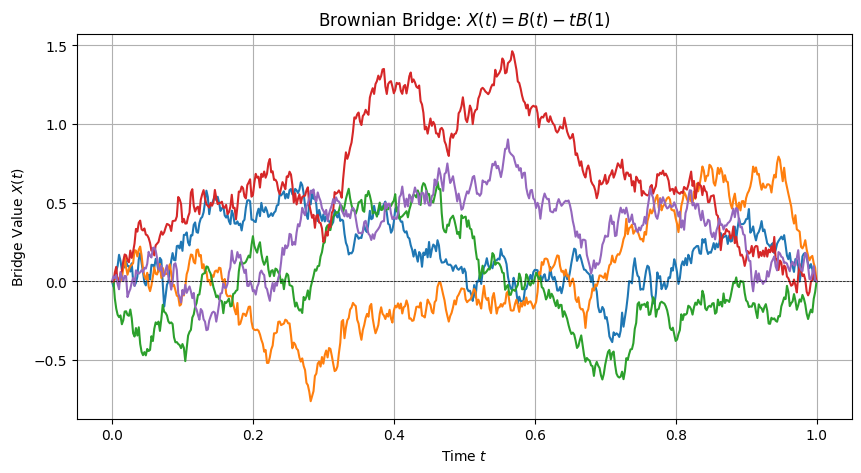

In [6]:
n_paths = 1000
n_steps = 500
t, bridge_paths = simulate_brownian_bridge(n_paths, n_steps)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(t, bridge_paths[i, :], lw=1.5)

plt.title("Brownian Bridge: $X(t) = B(t) - tB(1)$")
plt.xlabel("Time $t$")
plt.ylabel("Bridge Value $X(t)$")
plt.axhline(0, color='black', lw=0.5, ls='--') # Add a dashed horizontal line at y=0 to visually confirm that all paths start and end at 0.
plt.grid()
plt.show()

## Theoretical Covariance Verification

In [7]:
idx_s = int(0.2*n_steps)
idx_t = int(0.5*n_steps)

# Extract the values at times s and t across all bridge paths 
X_s = bridge_paths[:, idx_s]
X_t = bridge_paths[:, idx_t]

cov_matrix = np.cov(X_s, X_t)
print(f"Theoretical Covariance: {min(0.2, 0.5) - 0.2*0.5} = {min(0.2, 0.5) - 0.2*0.5}")
print(f"Empirical Covariance: {cov_matrix[0, 1].round(4)}")

Theoretical Covariance: 0.1 = 0.1
Empirical Covariance: 0.1087
